In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("LargestCompanies.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5943 entries, 0 to 5942
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         5943 non-null   int64  
 1   Name         5943 non-null   object 
 2   Symbol       5943 non-null   object 
 3   marketcap    5943 non-null   int64  
 4   price (USD)  5943 non-null   float64
 5   country      5943 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 278.7+ KB


In [8]:
df.isna().sum()
# NaN

Rank           0
Name           0
Symbol         0
marketcap      0
price (USD)    0
country        0
dtype: int64

In [10]:
df["marketcap"] = df["marketcap"]/1000000000000

In [12]:
df["marketcap"] = df["marketcap"].round(2)

In [32]:
df.head()
# How many unique countries are the dataset
df["country"].unique()

array(['United States', 'Saudi Arabia', 'Taiwan', 'China', 'South Korea',
       'France', 'Switzerland', 'Japan', 'Netherlands', 'Australia',
       'Denmark', 'Ireland', 'India', 'United Kingdom', 'Canada',
       'Germany', 'Hong Kong', 'Belgium', 'Russia', 'Norway', 'Brazil',
       'Spain', 'Singapore', 'Italy', 'Sweden', 'Indonesia', 'Mexico',
       'Austria', 'Argentina', 'Finland', 'Thailand', 'South Africa',
       'Colombia', 'Luxembourg', 'Malaysia', 'Czech Republic', 'Portugal',
       'Bermuda', 'Israel', 'Chile', 'Hungary', 'Poland', 'Isle of Man',
       'New Zealand', 'BM', 'Turkey', 'Uruguay', 'Greece', 'Philippines',
       'Jersey', 'Cyprus', 'Egypt', 'Macau', 'Iceland', 'Kazakhstan',
       'Romania', 'Cayman Islands', 'Panama', 'Malta', 'Peru', 'Guernsey',
       'Nigeria', 'Monaco', 'Lithuania', 'Costa Rica', 'Bahamas',
       'United Arab Emirates', 'Estonia'], dtype=object)

In [22]:
# How many companies located in United Kingdom?
df[df["country"]=="United Kingdom"].count().iloc[0]

108

In [28]:
countries = df.groupby("country").count()["Name"]
countries.loc["United Kingdom"]

108

In [29]:
countries.loc["Japan"]

224

In [35]:
countries_vc = df["country"].value_counts()
countries_vc.loc["United Kingdom"]

108

In [37]:
df["country"].value_counts(True)
# get 5 top countries by marketcap

country
United States    0.548376
India            0.089181
Japan            0.037691
Canada           0.035504
China            0.032307
                   ...   
Nigeria          0.000168
Lithuania        0.000168
Costa Rica       0.000168
BM               0.000168
Estonia          0.000168
Name: proportion, Length: 68, dtype: float64

In [38]:
cap = df.groupby("country")["marketcap"].sum().nlargest(5)
cap

country
United States    46.13
China             7.14
Japan             4.36
France            2.85
India             2.79
Name: marketcap, dtype: float64

In [39]:
x = cap.index
y = cap.values

In [62]:
av = cap.mean()
av

12.654

In [64]:
# help(plt.hlines)

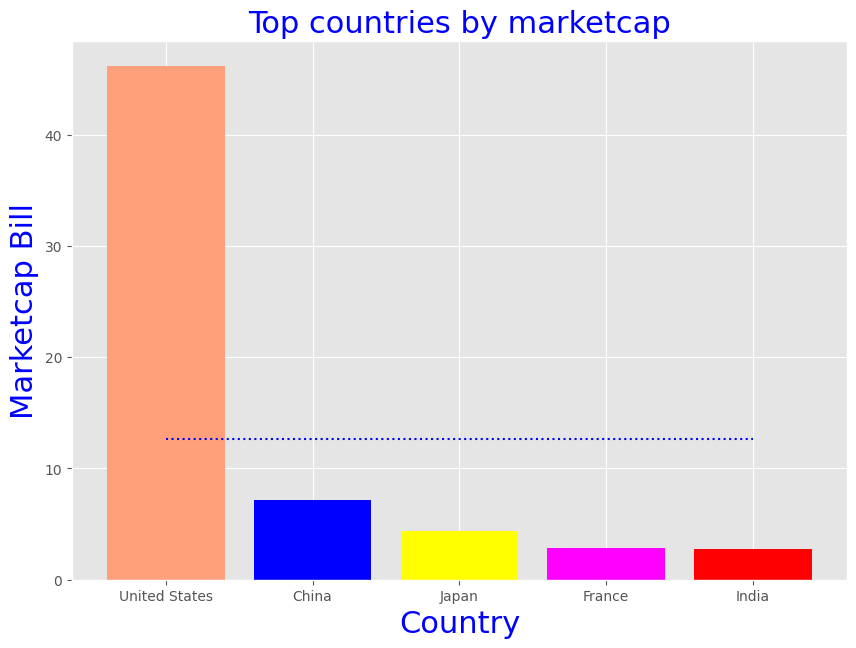

In [68]:
c = ["#FFA07A","#0000FF","#FFFF00","#FF00FF","#FF0000"]
plt.figure(figsize=(10,7))
plt.style.use('ggplot')
plt.bar(x=x, height=y, color=c)
plt.hlines(av, xmin="United States",xmax="India",linestyles=":",color="blue")
plt.title("Top countries by marketcap", color="blue", fontsize=22)
plt.ylabel("Marketcap Bill", color="blue",fontsize=22)
plt.xlabel("Country", color="blue",fontsize=22);
plt.savefig("Best Plot Ever.png")

In [78]:
# How many companies have price less than 100?
df[df["price (USD)"]<100].drop_duplicates(subset=['Name']).count().iloc[0]

5129

In [85]:
d = df[df["price (USD)"]<100]
d[d["Name"].duplicated()]

,Rank,Name,Symbol,marketcap,price (USD),country
5043,5044,First Bancorp,FNLC,0.0,31.59,United States


In [86]:
d[d["Name"]=="First Bancorp"]

,Rank,Name,Symbol,marketcap,price (USD),country
3790,3791,First Bancorp,FBNC,0.0,44.65,United States
5043,5044,First Bancorp,FNLC,0.0,31.59,United States
